In [3]:
import json, os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [4]:
bug_list_file = './bugs_list.txt'
with open(bug_list_file, 'r') as f:
    bug_list = f.read().splitlines()

print(bug_list)

['Chart_1', 'Chart_10', 'Chart_11', 'Chart_12', 'Chart_13', 'Chart_15', 'Chart_17', 'Chart_20', 'Chart_24', 'Chart_26', 'Chart_3', 'Chart_4', 'Chart_5', 'Chart_6', 'Chart_7', 'Chart_8', 'Chart_9', 'Lang_1', 'Lang_10', 'Lang_11', 'Lang_12', 'Lang_14', 'Lang_16', 'Lang_17', 'Lang_18', 'Lang_19', 'Lang_21', 'Lang_22', 'Lang_24', 'Lang_26', 'Lang_27', 'Lang_28', 'Lang_29', 'Lang_3', 'Lang_31', 'Lang_33', 'Lang_35', 'Lang_37', 'Lang_38', 'Lang_39', 'Lang_40', 'Lang_42', 'Lang_43', 'Lang_44', 'Lang_45', 'Lang_48', 'Lang_49', 'Lang_5', 'Lang_51', 'Lang_52', 'Lang_53', 'Lang_54', 'Lang_55', 'Lang_57', 'Lang_58', 'Lang_59', 'Lang_6', 'Lang_60', 'Lang_61', 'Lang_62', 'Lang_64', 'Lang_65', 'Lang_9', 'Math_10', 'Math_100', 'Math_101', 'Math_102', 'Math_103', 'Math_105', 'Math_106', 'Math_11', 'Math_13', 'Math_14', 'Math_15', 'Math_16', 'Math_17', 'Math_19', 'Math_2', 'Math_20', 'Math_21', 'Math_23', 'Math_24', 'Math_25', 'Math_26', 'Math_27', 'Math_28', 'Math_3', 'Math_30', 'Math_31', 'Math_32', '

In [5]:
d4j_bug_list = os.listdir('../AutoFL/data/defects4j')

In [30]:
d4j_combined_results_file = '../AutoFL/combined_fl_results/d4j_eol_qwen2.5-coder_R5.json'
with open(d4j_combined_results_file, 'r') as f:
    d4j_combined_result = json.load(f)

In [31]:
d4j_fl_success = dict()

d4j_confidence = dict()

for bug in bug_list:
    if bug in d4j_bug_list:
        buggy_methods = d4j_combined_result["buggy_methods"][bug]
        if len(buggy_methods) != 1:
            pass
        else:
            method_name, method_info = next(iter(buggy_methods.items()))
            if method_info.get("autofl_rank") == 1:
                d4j_fl_success[bug] = True
            else:
                d4j_fl_success[bug] = False
        
        confidence = d4j_combined_result["confidence"]
        d4j_confidence[bug] = confidence[bug]


In [32]:
all_confidences = []
all_labels = []

for bug in bug_list:
    if bug in d4j_bug_list:
        buggy_methods = d4j_combined_result["buggy_methods"][bug]
        if len(buggy_methods) != 1:
            # print(project)
            pass
        else:
            method_name, method_info = next(iter(buggy_methods.items()))
            if method_info.get("autofl_rank") == 1:
                all_labels.append(1)
            else:
                all_labels.append(0)
        
        all_confidences.append(d4j_combined_result["confidence"][bug])


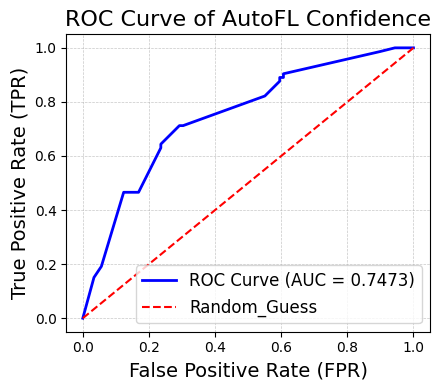

In [33]:
fpr, tpr, threshold = roc_curve(all_labels, all_confidences)
roc_auc = roc_auc_score(all_labels, all_confidences)

plt.figure(figsize=(4.5, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1.5, label='Random_Guess')  # Random prediction line
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve of AutoFL Confidence', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()  # Ensure everything fits well
plt.savefig("./figures/Figure_AutoFL_ROC_AUC.pdf", format="pdf", dpi=300)
plt.show()


### get_classification acc

In [34]:
num_correct = 0

for confidence, label in zip(all_confidences, all_labels):
    if (confidence >= 0.5 and label == 1) or (confidence < 0.5 and label == 0):
        num_correct += 1

classification_acc = num_correct/len(all_confidences)
print(f"{classification_acc:.4f}")

0.7099


### Get precision

In [35]:
num_precise = 0
num_predict_true = 0

for confidence, label in zip(all_confidences, all_labels):
    if confidence >= 0.5:
        num_predict_true += 1
        if label == 1:
            num_precise += 1

precision = num_precise / num_predict_true
print(f"{precision:.4f}")

0.6667


### Get recall

In [36]:
num_true_positive = 0
num_positive = 0

for confidence, label in zip(all_confidences, all_labels):
    if label == 1:
        num_positive += 1
        if confidence >= 0.5:
            num_true_positive += 1
        

recall = num_true_positive / num_positive
print(f"{recall:.4f}")

0.7123


### Baseline

In [37]:
print(f"{sum(all_labels)/len(all_labels):.4f}")

0.4506
